In [2]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, normalize

# dim reduction
import umap.umap_ as umap     # if this doesn't come up, just comment it out ;
# you can try pip install umap in colab but DO NOT do it in your global env (or else end up like me with pandas issues)
from sklearn.random_projection import GaussianRandomProjection

# similarity, distance
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist

# clustering diagnostics -- decide number of components, evaluates cluster quality
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

## Import data

In [3]:
# embeddings
X_text = np.load("/content/drive/MyDrive/Met Project Testing/text_embeddings.npy")
X_image = np.load("/content/drive/MyDrive/Met Project Testing/clip_embeddings.npy")
X_joint = np.load("/content/drive/MyDrive/Met Project Testing/joint_embeddings.npy")

meta = pd.read_csv("/content/drive/MyDrive/Met Project Testing/metadata.csv")

#I will primarily test on the joint embeddings
X = X_joint.copy()

print("text:", X_text.shape)
print("image:", X_image.shape)
print("joint:", X_joint.shape)
print("metadata rows:", len(meta))

text: (44973, 384)
image: (44973, 512)
joint: (44973, 896)
metadata rows: 44973


In [4]:
# check basic structure
print("NaN count:", np.isnan(X).sum())
print("Inf count:", np.isinf(X).sum())

norms = np.linalg.norm(X, axis=1)
print(norms)
pd.Series(norms).describe()

#I think the pipeline outputs embeddings already normalized to L2, which is why it is so clean over here

NaN count: 0
Inf count: 0
[1. 1. 1. ... 1. 1. 1.]


,0
count,4.497300e+04
mean,1.000000e+00
std,2.838910e-08
min,9.999998e-01
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


## See if we should normalize or not (probably yes)

In [5]:
# normalize or not? - GMM assumes Euclidean structure, so normalization choice matters A LOT!!!!
X = normalize(X)

## PCA

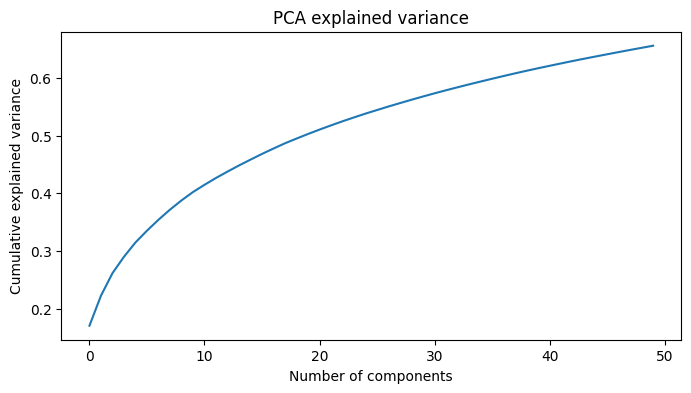

In [8]:
# pca
pca = PCA(n_components=50, random_state = 4654)
X_pca = pca.fit_transform(X)

cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(cum_var)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.show()

## Visualize Clusters

In [18]:
#UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_pca)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


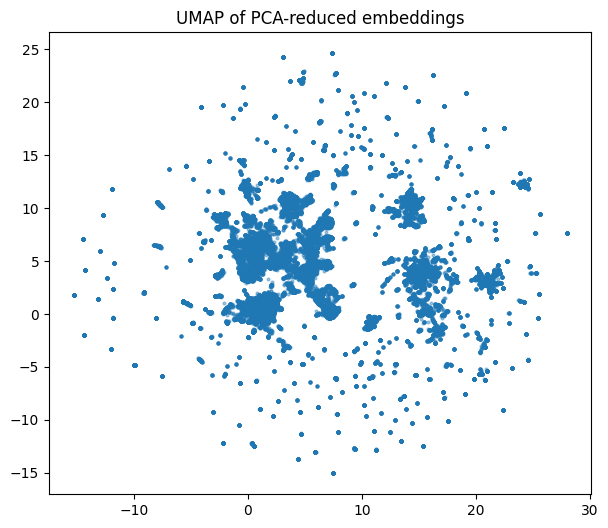

In [19]:
  plt.figure(figsize=(7, 6))
  plt.scatter(X_umap[:, 0], X_umap[:, 1], s=4, alpha=0.4)
  plt.title("UMAP of PCA-reduced embeddings")
  plt.show()

NameError: name 'tsne_idx' is not defined

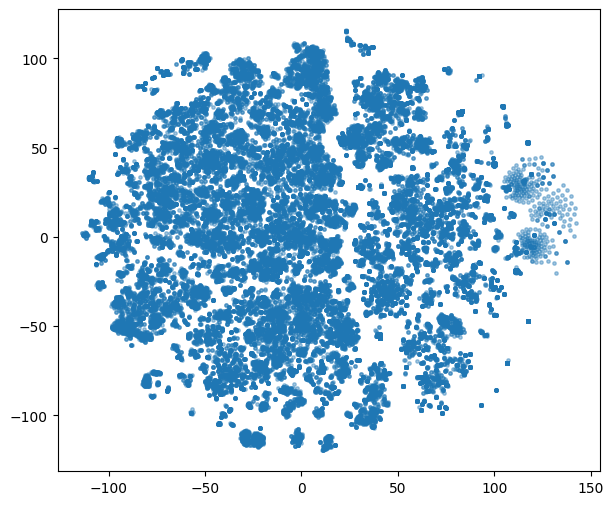

In [21]:
#tsne
X_tsne = TSNE(n_components=2, init="pca", learning_rate="auto", random_state=42).fit_transform(X_pca)



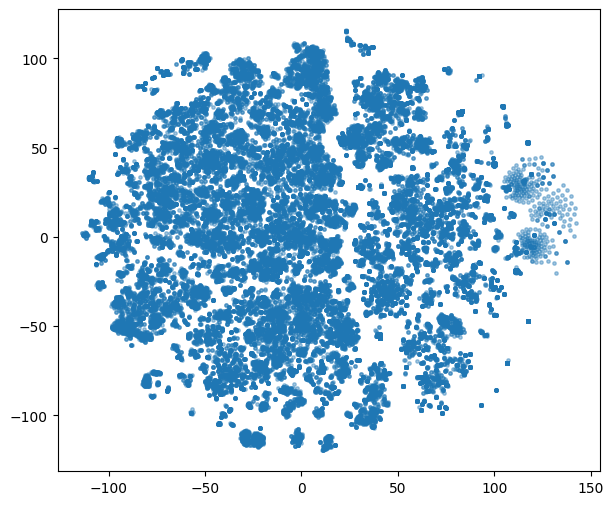

In [22]:
plt.figure(figsize=(7, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=6, alpha=0.4)
plt.show()

## Check similarity strucutre

- GMM assumes Gaussian in Euclidean space
- if embeddings are cosine-based, normalize + consider spherical clustering ideas

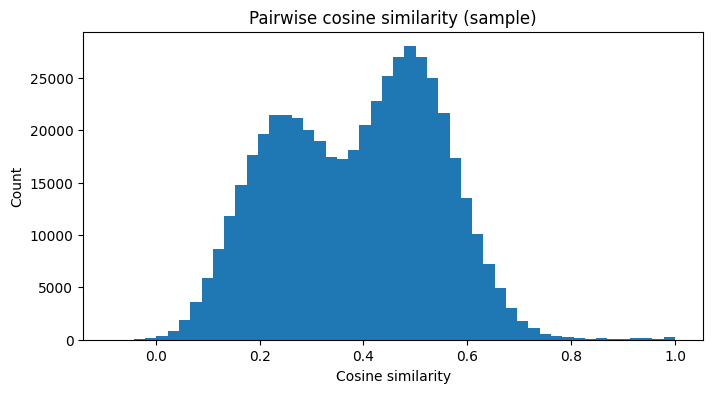

,0
count,499500.000000
mean,0.387467
std,0.155191
min,-0.085640
25%,0.258526
50%,0.401632
75%,0.508695
max,1.000000


In [6]:
# cosine similarity
sample_idx = np.random.default_rng(42).choice(X.shape[0], size=min(1000, X.shape[0]), replace=False)
cos_sim = cosine_similarity(X[sample_idx])
upper = cos_sim[np.triu_indices_from(cos_sim, k=1)]

plt.figure(figsize=(8, 4))
plt.hist(upper, bins=50)
plt.title("Pairwise cosine similarity (sample)")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.show()

pd.Series(upper).describe()

## Try K-means clustering (just to see)

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state = 42, n_init=10)
labels = kmeans.fit_predict(X_pca)

print("KMeans silhouette:", silhouette_score(X_pca, labels))
print("KMeans Davies-Bouldin:", davies_bouldin_score(X_pca, labels))
pd.Series(labels).value_counts().sort_index()

KMeans silhouette: 0.106275246
KMeans Davies-Bouldin: 2.9267907181826622


,count
0,7632
1,9481
2,10178
3,12914
4,4768


## Try GMM

In [14]:
gmm = GaussianMixture(n_components=5, covariance_type="diag", random_state=42)
gmm.fit(X_pca)
labels = gmm.predict(X_pca)
print("GMM converged:", gmm.converged_)
print("GMM lower bound:", gmm.lower_bound_)
print("GMM silhouette:", silhouette_score(X_pca, labels))
print("GMM Davies-Bouldin:", davies_bouldin_score(X_pca, labels))
pd.Series(labels).value_counts().sort_index()

GMM converged: True
GMM lower bound: 63.60585544033489
GMM silhouette: 0.09710277
GMM Davies-Bouldin: 2.8701636578831122


,count
0,14252
1,6451
2,7420
3,5640
4,11210


## Store the Fitted GMM Artifacts Offline

In [15]:
# save fitted GMM artifacts so we do not need to refit later
import os

output_dir = "gmm_artifacts"
os.makedirs(output_dir, exist_ok=True)

gmm_means = final_gmm.means_
gmm_means_l2 = normalize(gmm_means) #Since we are doing cosine similarity later
gmm_covariances = final_gmm.covariances_
gmm_weights = final_gmm.weights_
cluster_assignments = final_labels #Predictions using GMM
responsibilities = final_gmm.predict_proba(X_pca) #Predictions using GMM

np.save(os.path.join(output_dir, "gmm_means.npy"), gmm_means)
np.save(os.path.join(output_dir, "gmm_means_l2.npy"), gmm_means_l2)
np.save(os.path.join(output_dir, "gmm_covariances.npy"), gmm_covariances)
np.save(os.path.join(output_dir, "gmm_weights.npy"), gmm_weights)
np.save(os.path.join(output_dir, "cluster_assignments.npy"), cluster_assignments)
np.save(os.path.join(output_dir, "responsibilities.npy"), responsibilities)

# because the GMM was fit on PCA-space embeddings, future queries need the same PCA transform
np.save(os.path.join(output_dir, "pca_components.npy"), pca.components_)
np.save(os.path.join(output_dir, "pca_mean.npy"), pca.mean_)
np.save(os.path.join(output_dir, "pca_explained_variance_ratio.npy"), pca.explained_variance_ratio_)

print("Saved GMM artifacts to:", output_dir)
print(sorted(os.listdir(output_dir)))

NameError: name 'final_gmm' is not defined